* Importing libraries

In [ ]:
import numpy as np
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import StratifiedKFold

* Load the Fashion-MNIST dataset

In [ ]:
# 1. Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print('Original Fashion-MNIST train shape:', x_train.shape)
print('Original Fashion-MNIST test shape:', x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original Fashion-MNIST train shape: (60000, 28, 28)
Original Fashion-MNIST test shape: (10000, 28, 28)


* Normalize the data in range [0,1]

In [ ]:
# 2. Normalize the data in range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

* Channel dimension

In [ ]:
# 3. Add a channel dimension (needed for CNNs)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Save the original labels before One-Hot Encoding (for K-Fold)
y_train_original = y_train.copy()
y_test_original = y_test.copy()

* One-hot encoding

In [ ]:
# 4. Do a one-hot-encoding for the outputs (10 classes of clothes)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

* Data Visualization

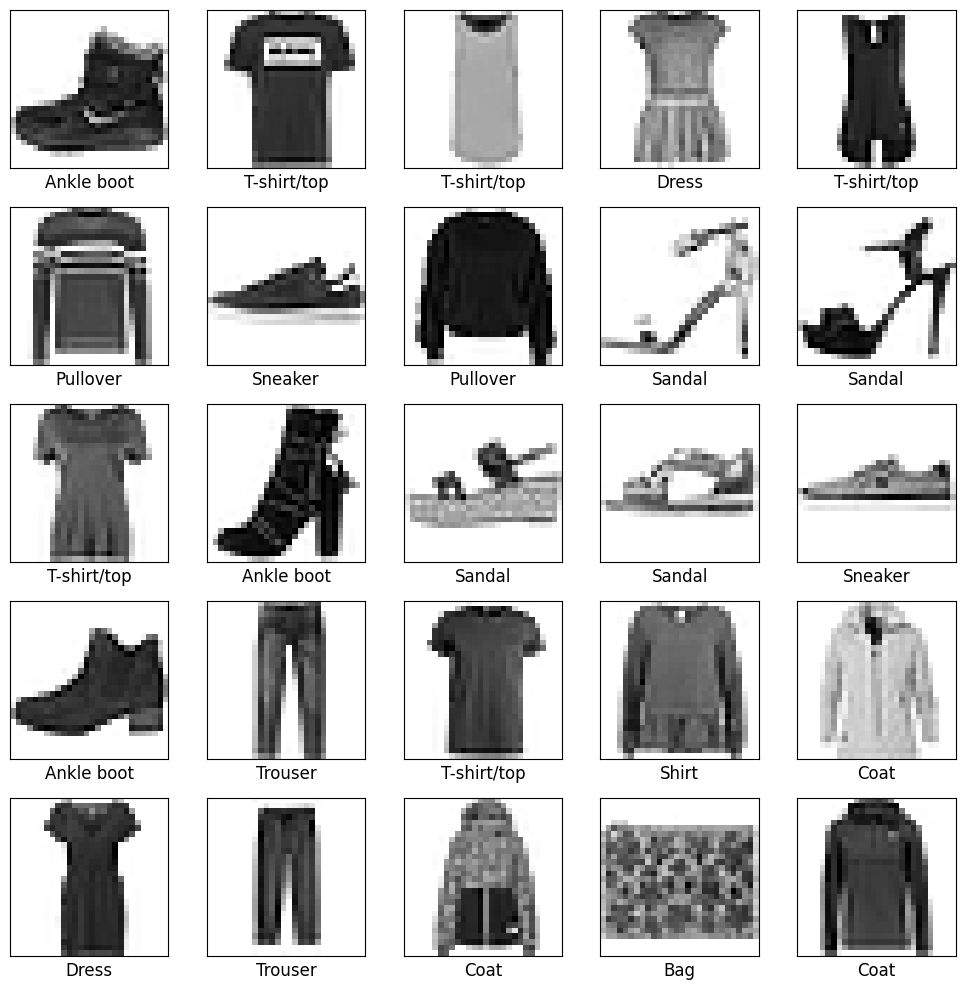

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# Load the data (we only need the train set to show images)
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# These are the actual names of the 10 Fashion-MNIST categories in English
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Create a figure with size 10x10 inches
plt.figure(figsize=(10, 10))

# Print the first 25 images of the dataset in a 5x5 grid
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([]) # Hide X axes
    plt.yticks([]) # Hide Y axes
    plt.grid(False)

    # Display the image (in grayscale)
    plt.imshow(x_train[i], cmap=plt.cm.binary)

    # Use the clothing name corresponding to the label number as the title
    plt.xlabel(class_names[y_train[i]], fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

# Save the image
plt.savefig('fashion_mnist_images.png')

* Define the K-Fold cross validation process

In [ ]:
# 5. Define the K-Fold cross validation process
k_folds = 6
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

* DNN function

In [ ]:
# Function to create a fresh DNN from scratch
def create_dnn_model():
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28, 1)))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model

* CNN function

In [ ]:
# Function to create a fresh CNN from scratch
def create_cnn_model():
    model = Sequential()
    model.add(Conv2D(6, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(12, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model

In [ ]:
print("\nFashion-MNIST data loaded, preprocessed, and functions defined successfully!")


Fashion-MNIST data loaded, preprocessed, and functions defined successfully!


* Transfer Learning Builder

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# TRANSFER LEARNING MODEL BUILDER
# ==========================================

def create_transfer_model(saved_model_path):
    # 1. Load the pre-trained model (trained on MNIST from Question 1)
    base_model = keras.models.load_model(saved_model_path)

    # 2. Create a new, empty Sequential model
    transfer_model = Sequential()

    # 3. Loop through all layers of the loaded model EXCEPT the last one ([:-1])
    for layer in base_model.layers[:-1]:
        # Freeze the layer so its pre-trained weights don't change
        layer.trainable = False
        # Add the frozen layer to our new model
        transfer_model.add(layer)

    # 4. Add a fresh classification layer for Fashion-MNIST (10 clothing classes)
    transfer_model.add(Dense(10, activation='softmax'))

    return transfer_model

print("Transfer learning helper function defined (Sequential approach)!")

Transfer learning helper function defined (Sequential approach)!


* Metrics Function

In [ ]:
# ==========================================
# METRICS EVALUATION HELPER
# ==========================================

def evaluate_and_append(model, x_tr, y_tr_true, x_te, y_te_true, tech_name, fold_n, results_list):
    # Predict on Train Set
    train_preds = np.argmax(model.predict(x_tr, verbose=0), axis=1)

    # Predict on Test Set
    test_preds = np.argmax(model.predict(x_te, verbose=0), axis=1)

    # Calculate Metrics for Train Set
    tr_acc = accuracy_score(y_tr_true, train_preds)
    tr_prec = precision_score(y_tr_true, train_preds, average='macro', zero_division=0)
    tr_rec = recall_score(y_tr_true, train_preds, average='macro', zero_division=0)
    tr_f1 = f1_score(y_tr_true, train_preds, average='macro', zero_division=0)

    # Calculate Metrics for Test Set
    te_acc = accuracy_score(y_te_true, test_preds)
    te_prec = precision_score(y_te_true, test_preds, average='macro', zero_division=0)
    te_rec = recall_score(y_te_true, test_preds, average='macro', zero_division=0)
    te_f1 = f1_score(y_te_true, test_preds, average='macro', zero_division=0)

    # Append to our tracking list
    results_list.append([tech_name, "Train", fold_n, tr_acc, tr_prec, tr_rec, tr_f1])
    results_list.append([tech_name, "Test", fold_n, te_acc, te_prec, te_rec, te_f1])

print("Metrics helper function defined!")

Metrics helper function defined!


* Training

In [ ]:
# ==========================================
# THE MAIN K-FOLD LOOP
# ==========================================

results_list_q2 =[]
y_test_true = np.argmax(y_test, axis=1)

# Training Parameters (As requested by the assignment)
EPOCHS_SCRATCH = 150       # Warning: This will take a long time!
EPOCHS_TRANSFER_FROZEN = 40
EPOCHS_TRANSFER_FINE = 20
BATCH_SIZE = 128

for fold_index, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train_original)):
    fold_num = fold_index + 1
    print(f"\n{'='*50}")
    print(f"STARTING FOLD {fold_num} / 6")
    print(f"{'='*50}")

    # Create the independent Train and Validation sets for this fold
    x_fold_train, y_fold_train = x_train[train_idx], y_train[train_idx]
    x_fold_val, y_fold_val = x_train[val_idx], y_train[val_idx]
    y_fold_train_true = np.argmax(y_fold_train, axis=1)

    # ---------------------------------------------------------
    # PART A: TRAINING FROM SCRATCH (DNN & CNN)
    # ---------------------------------------------------------

    print("\n---> Training DNN_from_scratch...")
    dnn_scratch = create_dnn_model()
    dnn_scratch.fit(x_fold_train, y_fold_train, validation_data=(x_fold_val, y_fold_val),
                    epochs=EPOCHS_SCRATCH, batch_size=BATCH_SIZE, verbose=0) # verbose=0 keeps output clean
    evaluate_and_append(dnn_scratch, x_fold_train, y_fold_train_true, x_test, y_test_true,
                        "DNN_from_scratch", fold_num, results_list_q2)

    print("---> Training CNN_from_scratch...")
    cnn_scratch = create_cnn_model()
    cnn_scratch.fit(x_fold_train, y_fold_train, validation_data=(x_fold_val, y_fold_val),
                    epochs=EPOCHS_SCRATCH, batch_size=BATCH_SIZE, verbose=0)
    evaluate_and_append(cnn_scratch, x_fold_train, y_fold_train_true, x_test, y_test_true,
                        "CNN_from_scratch", fold_num, results_list_q2)

    # ---------------------------------------------------------
    # PART B: TRANSFER LEARNING (DNN & CNN)
    # ---------------------------------------------------------

    # Dictionary mapping the technique name to the corresponding saved .h5 model
    transfer_models_to_run = {
        "DNN_transfer": 'best_dnn_model.h5',
        "CNN_transfer": 'best_cnn_model.h5'
    }

    for tech_name, model_path in transfer_models_to_run.items():
        print(f"\n---> Running Transfer Learning for {tech_name}...")

        # 1. Load model inside the fold (Assignment Rule 5d)
        t_model = create_transfer_model(model_path)

        # 2. Phase 1: Train ONLY the last layer (Layers are frozen from the helper function)
        print("     Phase 1: Training frozen model (40 epochs)...")
        t_model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
        t_model.fit(x_fold_train, y_fold_train, validation_data=(x_fold_val, y_fold_val),
                    epochs=EPOCHS_TRANSFER_FROZEN, batch_size=BATCH_SIZE, verbose=0)

        # 3. Phase 2: Unfreeze and Fine-Tune End-to-End
        print("     Phase 2: Fine-Tuning unfreezed model (20 epochs)...")
        for layer in t_model.layers:
            layer.trainable = True # Unfreeze all layers

        # Crucial: We MUST recompile the model after changing 'trainable' properties
        t_model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
        t_model.fit(x_fold_train, y_fold_train, validation_data=(x_fold_val, y_fold_val),
                    epochs=EPOCHS_TRANSFER_FINE, batch_size=BATCH_SIZE, verbose=0)

        # 4. Evaluate and save metrics
        evaluate_and_append(t_model, x_fold_train, y_fold_train_true, x_test, y_test_true,
                            tech_name, fold_num, results_list_q2)




STARTING FOLD 1 / 6

---> Training DNN_from_scratch...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


---> Training CNN_from_scratch...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



---> Running Transfer Learning for DNN_transfer...
     Phase 1: Training frozen model (40 epochs)...
     Phase 2: Fine-Tuning unfreezed model (20 epochs)...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


---> Training CNN_from_scratch...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



---> Running Transfer Learning for DNN_transfer...
     Phase 1: Training frozen model (40 epochs)...
     Phase 2: Fine-Tuning unfreezed model (20 epochs)...



---> Running Transfer Learning for CNN_transfer...
     Phase 1: Training frozen model (40 epochs)...
     Phase 2: Fine-Tuning unfreezed model (20 epochs)...


* Results

In [ ]:
# ==========================================
# EXPORT RESULTS TO CSV
# ==========================================

columns_names = ['Technique name', 'Set', 'Fold number', 'Accuracy', 'Precision', 'Recall', 'F1 score']
df_results_q2 = pd.DataFrame(results_list_q2, columns=columns_names)

# Save the DataFrame to a CSV file
df_results_q2.to_csv('erotima2.csv', index=False)

print("\nAll folds completed successfully!")
print("Results saved to 'erotima2.csv' (Total rows:", len(df_results_q2), ")")
display(df_results_q2.head(10)) # Display first 10 rows just to check


All folds completed successfully!
Results saved to 'erotima2.csv' (Total rows: 48 )


,Technique name,Set,Fold number,Accuracy,Precision,Recall,F1 score
0,DNN_from_scratch,Train,1,0.87022,0.874158,0.87022,0.870950
1,DNN_from_scratch,Test,1,0.85490,0.859317,0.85490,0.855730
2,CNN_from_scratch,Train,1,0.84920,0.847897,0.84920,0.846157
3,CNN_from_scratch,Test,1,0.83880,0.837242,0.83880,0.836150
4,DNN_transfer,Train,1,0.86316,0.866408,0.86316,0.860506
5,DNN_transfer,Test,1,0.85020,0.853216,0.85020,0.847659
6,CNN_transfer,Train,1,0.86036,0.860651,0.86036,0.857585
7,CNN_transfer,Test,1,0.84910,0.848949,0.84910,0.846261
8,DNN_from_scratch,Train,2,0.86966,0.869816,0.86966,0.869531
9,DNN_from_scratch,Test,2,0.85440,0.854453,0.85440,0.854244


* Plot drawing

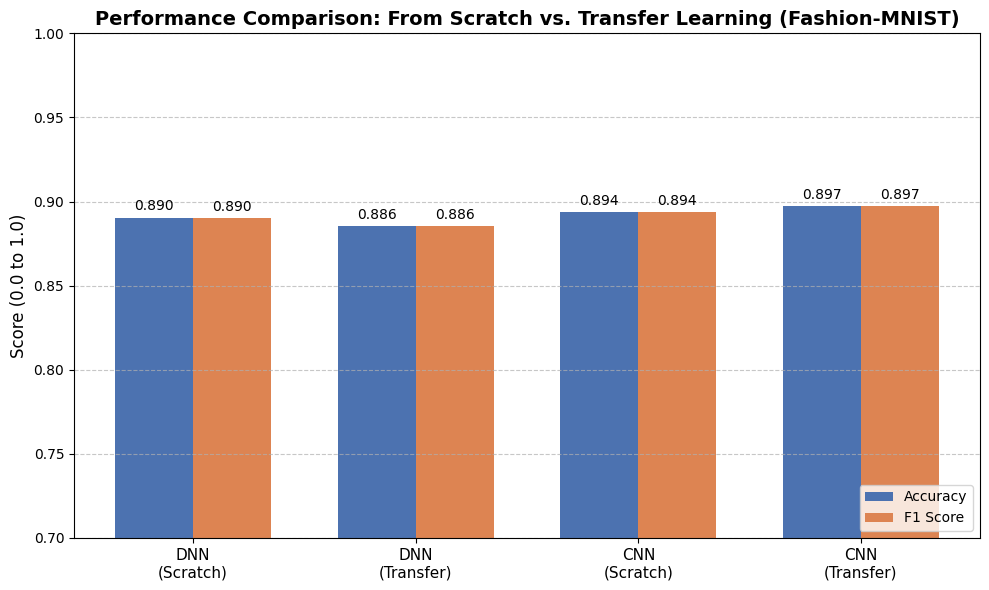

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Διαβάζουμε το CSV με τα αποτελέσματα του Ερωτήματος 2
df = pd.read_csv('erotima2.csv')

# 2. Κρατάμε μόνο το Test Set
test_df = df[df['Set'] == 'Test'].copy()

# 3. Υπολογίζουμε τον μέσο όρο (mean) στα 6 Folds για κάθε Τεχνική
summary = test_df.groupby('Technique name')[['Accuracy', 'F1 score']].mean().reset_index()

# 4. Βάζουμε τις τεχνικές στη σωστή σειρά για να φαίνονται όμορφα στο γράφημα
order = ['DNN_from_scratch', 'DNN_transfer', 'CNN_from_scratch', 'CNN_transfer']
summary['Technique name'] = pd.Categorical(summary['Technique name'], categories=order, ordered=True)
summary = summary.sort_values('Technique name')

# --- ΔΗΜΙΟΥΡΓΙΑ ΤΟΥ ΓΡΑΦΗΜΑΤΟΣ ---
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(summary['Technique name']))
width = 0.35  # Το πάχος της κάθε ράβδου

# Φτιάχνουμε τις ράβδους για Accuracy (Μπλε) και F1-Score (Πορτοκαλί)
rects1 = ax.bar(x - width/2, summary['Accuracy'], width, label='Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, summary['F1 score'], width, label='F1 Score', color='#DD8452')

# Προσθέτουμε τίτλους και ρυθμίσεις
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('Performance Comparison: From Scratch vs. Transfer Learning (Fashion-MNIST)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['DNN\n(Scratch)', 'DNN\n(Transfer)', 'CNN\n(Scratch)', 'CNN\n(Transfer)'], fontsize=11)
ax.legend(loc='lower right')

# Βάζουμε τα ακριβή νούμερα πάνω από κάθε ράβδο (για να φαίνεται απόλυτα επαγγελματικό)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

# Βάζουμε όρια στον άξονα Υ για να φαίνονται καλύτερα οι διαφορές
# (Αν τα νούμερά σου είναι πιο χαμηλά από 0.70, άλλαξε το 0.70 στο παρακάτω σε 0.60 ή 0.50)
ax.set_ylim(0.70, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('perf_comp.png', dpi=300)

plt.show()